<a href="https://colab.research.google.com/github/csk01/lpg-cylinder-detection/blob/main/notebooks/lpg_classifier_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## v2 Training — experimenting w below changes and why

| What | Old | New | Why |
|---|---|---|---|
| Augmentation | Light jitter, flip, rotation | + GaussianBlur, Perspective, RandomErasing, Grayscale | Simulate aged/worn cylinders like real-world test images |
| Class imbalance | Loss weights only | `WeightedRandomSampler` | Physically rebalances what model sees per epoch |
| Architecture | EfficientNetB0 | EfficientNetB2 + Dropout(0.4) | Better features, extra regularisation |
| Loss | `CrossEntropyLoss` | + `label_smoothing=0.1` | Prevents overconfidence on ambiguous/noisy labels |
| Scheduler | `StepLR` | `CosineAnnealingLR (T_max=30)` | Smoother LR decay, better generalisation |

## Uploading classificaiton crops




In [1]:
from google.colab import files

uploaded = files.upload()

Saving sorted_crops.zip to sorted_crops.zip


In [2]:
import zipfile
with zipfile.ZipFile("sorted_crops.zip", 'r') as z:
    z.extractall("/content/")
print("Done!")

# Check counts
import os
for brand in ["indane", "bharat_gas", "hp_gas", "unknown"]:
    path = f"/content/sorted_crops/{brand}"
    if os.path.exists(path):
        print(f"{brand}: {len(os.listdir(path))} images")

Done!
indane: 260 images
bharat_gas: 142 images
hp_gas: 155 images
unknown: 101 images


## Train/Val split


In [3]:
import shutil
import random
from pathlib import Path

BASE = "/content/sorted_crops/"
OUTPUT = "/content/classifier_dataset"

brands = ["indane", "bharat_gas", "hp_gas", "unknown"]
splits = {"train": 0.8, "val": 0.2}

for brand in brands:
    files = os.listdir(f"{BASE}/{brand}")
    random.shuffle(files)

    n_train = int(len(files) * 0.8)
    train_files = files[:n_train]
    val_files = files[n_train:]

    for split, split_files in [("train", train_files), ("val", val_files)]:
        dest = f"{OUTPUT}/{split}/{brand}"
        os.makedirs(dest, exist_ok=True)
        for f in split_files:
            shutil.copy(f"{BASE}/{brand}/{f}", f"{dest}/{f}")

print("Split done!")
for split in ["train", "val"]:
    for brand in brands:
        count = len(os.listdir(f"{OUTPUT}/{split}/{brand}"))
        print(f"{split}/{brand}: {count}")

Split done!
train/indane: 208
train/bharat_gas: 113
train/hp_gas: 124
train/unknown: 80
val/indane: 52
val/bharat_gas: 29
val/hp_gas: 31
val/unknown: 21


In [4]:
#Check gpu
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
print(torch.cuda.is_available())  # should print True
print(torch.cuda.get_device_name(0))  # should say Tesla T4


True
NVIDIA A100-SXM4-40GB


## Tryin heavy augmentation to simulate real world cylinder wear and tear

In [5]:
from torchvision import transforms
import torchvision.transforms.functional as TF

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),

    # Simulate worn/faded/dirty labels
    transforms.ColorJitter(
        brightness=0.5,   # heavy — handles dark corners, shadows
        contrast=0.5,     # handles faded labels
        saturation=0.5,   # handles rust and paint loss
        hue=0.15          # handles color shift from aging
    ),

    # Force model off pure color cues
    transforms.RandomGrayscale(p=0.15),

    # Simulate blur from camera angle / distance
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),

    # Orientation variation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.4),

    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),

    # Randomly erase label regions — forces model to not just read text
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.0)),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("Transforms ready!")

Transforms ready!


### OVersample minority classes to fix imbalance

In [6]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets

OUTPUT = "/content/classifier_dataset"
train_data = datasets.ImageFolder(f"{OUTPUT}/train", transform=train_transforms)
val_data   = datasets.ImageFolder(f"{OUTPUT}/val",   transform=val_transforms)

# WeightedRandomSampler — minority classes get picked more often
class_counts = [len([f for f in train_data.targets if f == i]) for i in range(4)]
print(f"Train class counts: {dict(zip(train_data.classes, class_counts))}")

sample_weights = [1.0 / class_counts[label] for label in train_data.targets]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_data),
    replacement=True
)

train_loader = DataLoader(train_data, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False)

print(f"Classes: {train_data.classes}")
print(f"Train: {len(train_data)} | Val: {len(val_data)}")

Train class counts: {'bharat_gas': 113, 'hp_gas': 124, 'indane': 208, 'unknown': 80}
Classes: ['bharat_gas', 'hp_gas', 'indane', 'unknown']
Train: 525 | Val: 133


## UPgraded to EfficientNetB2 vs B0 + adding cosine annealing + label smoothing

In [7]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# EfficientNetB2 — slightly larger than B0, better feature extraction
# without being heavy enough to overfit on a small dataset
model = models.efficientnet_b2(weights="IMAGENET1K_V1")

# Add dropout before classifier to regularise
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(model.classifier[1].in_features, 4)
)
model = model.to(device)

# Label smoothing — stops model being overconfident on noisy labels
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Adam + cosine annealing as planned
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=30, eta_min=1e-6
)

print("Model ready!")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Using: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 178MB/s]


Model ready!
Trainable params: 7,706,630


## Training loop with best model saving:

In [8]:
from tqdm import tqdm

EPOCHS = 30
best_val_acc = 0.0

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    # --- Val ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    train_acc = train_correct / train_total * 100
    val_acc   = val_correct   / val_total   * 100

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.1f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.1f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "classifier_best_v2.pth")
        print(f"  ✅ New best saved: {val_acc:.1f}%")

    scheduler.step()

print(f"\nTraining complete. Best val acc: {best_val_acc:.1f}%")

Epoch 1/30 [Train]: 100%|██████████| 17/17 [00:10<00:00,  1.59it/s]


Epoch 01 | Train Loss: 1.2516 | Train Acc: 48.4% | Val Loss: 1.1381 | Val Acc: 62.4%
  ✅ New best saved: 62.4%


Epoch 2/30 [Train]: 100%|██████████| 17/17 [00:08<00:00,  2.04it/s]


Epoch 02 | Train Loss: 0.8999 | Train Acc: 73.7% | Val Loss: 0.8404 | Val Acc: 85.0%
  ✅ New best saved: 85.0%


Epoch 3/30 [Train]: 100%|██████████| 17/17 [00:08<00:00,  2.02it/s]


...

Epoch 28 | Train Loss: 0.3862 | Train Acc: 99.2% | Val Loss: 0.5329 | Val Acc: 94.7%


Epoch 29/30 [Train]: 100%|██████████| 17/17 [00:08<00:00,  2.02it/s]


Epoch 29 | Train Loss: 0.3952 | Train Acc: 98.9% | Val Loss: 0.5254 | Val Acc: 91.7%


Epoch 30/30 [Train]: 100%|██████████| 17/17 [00:08<00:00,  2.01it/s]


Epoch 30 | Train Loss: 0.4060 | Train Acc: 98.7% | Val Loss: 0.5324 | Val Acc: 94.0%

Training complete. Best val acc: 95.5%


### Saving model with metadata checkpoint for later review


In [9]:
from google.colab import files

torch.save({
    "model_state_dict": model.state_dict(),
    "best_val_acc": best_val_acc,
    "classes": train_data.classes,
    "architecture": "efficientnet_b2",
    "epochs_trained": EPOCHS,
}, "classifier_best_v2.pth")

print(f"Model saved! Best val acc: {best_val_acc:.1f}%")
files.download("classifier_best_v2.pth")

Model saved! Best val acc: 95.5%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Eval metrics


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.load_state_dict(torch.load("classifier_best_v2.pth")["model_state_dict"])
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = train_data.classes
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(all_labels, all_preds, target_names=class_names))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  bharat_gas       0.96      0.83      0.89        29
      hp_gas       0.86      0.97      0.91        31
      indane       0.96      1.00      0.98        52
     unknown       1.00      0.90      0.95        21

    accuracy                           0.94       133
   macro avg       0.95      0.93      0.93       133
weighted avg       0.94      0.94      0.94       133



## Confusion Martix heatmap




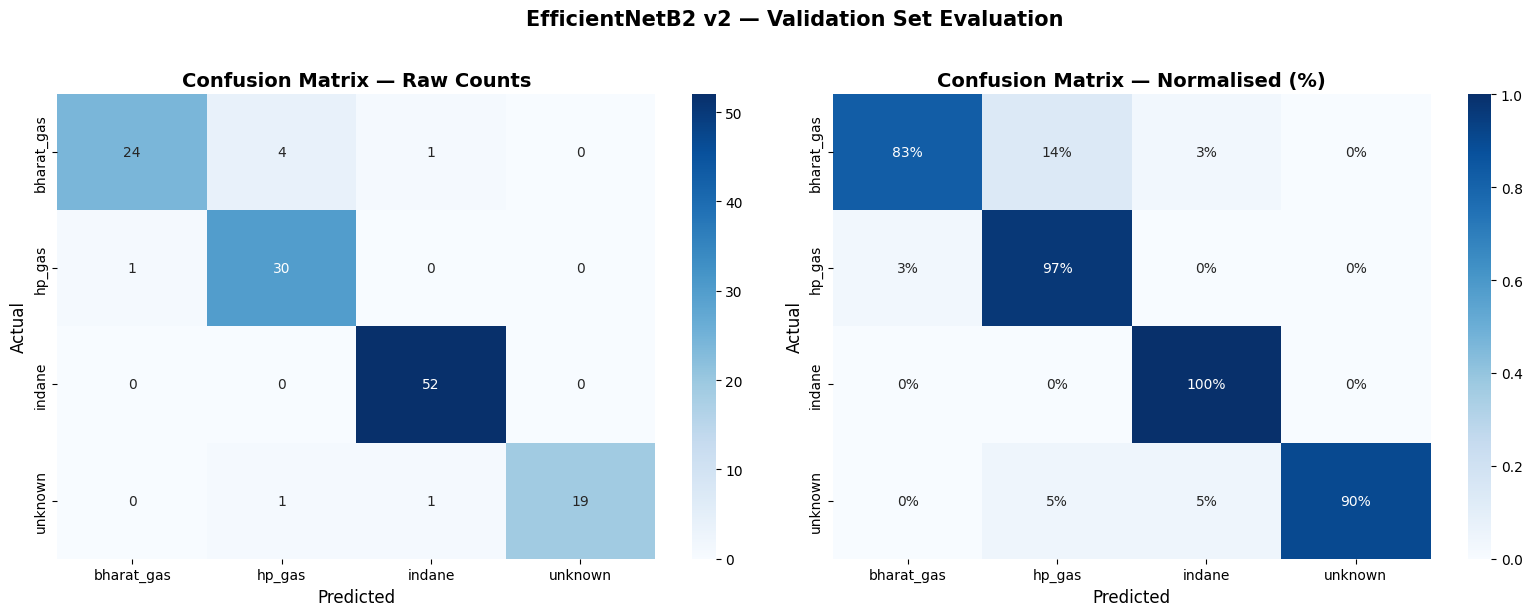

Saved: confusion_matrix_v2.png


In [12]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Confusion Matrix — Raw Counts", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Actual", fontsize=12)
axes[0].set_xlabel("Predicted", fontsize=12)

# Normalised %
sns.heatmap(cm_norm, annot=True, fmt=".0%", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Confusion Matrix — Normalised (%)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Actual", fontsize=12)
axes[1].set_xlabel("Predicted", fontsize=12)

plt.suptitle("EfficientNetB2 v2 — Validation Set Evaluation", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrix_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_v2.png")

## Per class accuracy plot


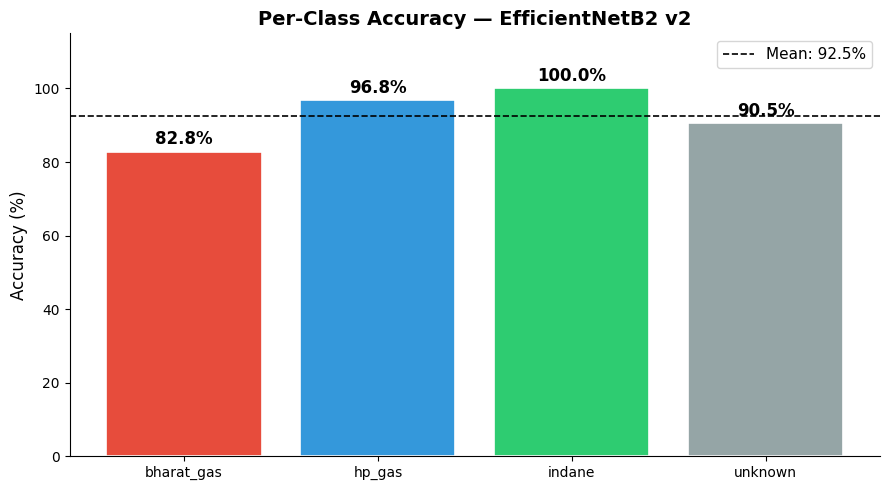

Saved: per_class_accuracy_v2.png


In [13]:
# @title
per_class_acc = cm_norm.diagonal() * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(class_names, per_class_acc,
              color=["#e74c3c", "#3498db", "#2ecc71", "#95a5a6"],
              edgecolor="white", linewidth=1.2)

# Value labels on bars
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{acc:.1f}%",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylim(0, 115)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Per-Class Accuracy — EfficientNetB2 v2", fontsize=14, fontweight="bold")
ax.axhline(y=per_class_acc.mean(), color="black", linestyle="--", linewidth=1.2,
           label=f"Mean: {per_class_acc.mean():.1f}%")
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("per_class_accuracy_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: per_class_accuracy_v2.png")

## Testing classifier model on unseen data